In [1]:
# 라이브러리 로드
import numpy as np
import pandas as pd
from IPython.display import display
from pprint import pprint

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
import platform


warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# 데이터프레임 출력제한 해제
pd.set_option('display.max_rows', None)      # 행 제한 해제
pd.set_option('display.max_columns', None)   # 열 제한 해제
pd.set_option('display.max_colwidth', None)  # 셀 내용 제한 해제

In [2]:
# FnB 데이터 로드
df_fnb_success = pd.read_csv("../../data/results/main_dataset/fnb_shorts_success_data.csv", encoding='utf-8')
df_fnb_fail = pd.read_csv("../../data/results/main_dataset/fnb_shorts_fail_data.csv", encoding='utf-8')

# IT 데이터 로드
df_it_success = pd.read_csv("../../data/results/main_dataset/it_shorts_success_data.csv", encoding='utf-8')
df_it_fail = pd.read_csv("../../data/results/main_dataset/it_shorts_fail_data.csv", encoding='utf-8')

In [3]:
print("[FnB 성공 영상 데이터]")
print(df_fnb_success.info())

print("[FnB 실패 영상 데이터]")
print(df_fnb_fail.info())

print("[IT 성공 영상 데이터]")
print(df_it_success.info())

print("[IT 실패 영상 데이터]")
print(df_it_fail.info())

[FnB 성공 영상 데이터]
<class 'pandas.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 56 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   video_id                    384 non-null    str    
 1   title                       384 non-null    str    
 2   channel_id                  384 non-null    str    
 3   채널명                         384 non-null    str    
 4   description                 384 non-null    str    
 5   업로드일시                       384 non-null    str    
 6   tags                        384 non-null    str    
 7   조회수                         384 non-null    int64  
 8   좋아요수                        384 non-null    float64
 9   댓글수                         384 non-null    float64
 10  영상길이(초)                     384 non-null    float64
 11  definition                  384 non-null    str    
 12  license                     384 non-null    str    
 13  embeddable                  38

### 1. 데이터 확인
- 성공/실패로 분류된 영상 수
- 해당 영상들을 갖고 있는 채널의 개수
- 채널별 영상 수 분포 (통계)

In [4]:
# 1. 성공/실패 영상 수
print(f"[FnB]")
print(f"성공 영상 수: {len(df_fnb_success)}개")
print(f"실패 영상 수: {len(df_fnb_fail)}개")

print(f"\n[IT]")
print(f"성공 영상 수: {len(df_it_success)}개")
print(f"실패 영상 수: {len(df_it_fail)}개")

# 2. 채널 수
print(f"\n[FnB 채널 수]")
print(f"성공 영상 채널 수: {df_fnb_success['채널명'].nunique()}개")
print(f"실패 영상 채널 수: {df_fnb_fail['채널명'].nunique()}개")

print(f"\n[IT 채널 수]")
print(f"성공 영상 채널 수: {df_it_success['채널명'].nunique()}개")
print(f"실패 영상 채널 수: {df_it_fail['채널명'].nunique()}개")

[FnB]
성공 영상 수: 384개
실패 영상 수: 413개

[IT]
성공 영상 수: 179개
실패 영상 수: 249개

[FnB 채널 수]
성공 영상 채널 수: 53개
실패 영상 채널 수: 25개

[IT 채널 수]
성공 영상 채널 수: 22개
실패 영상 채널 수: 11개


In [5]:
# 3. 채널별 영상 수 분포 통계
for name, df in [('FnB 성공', df_fnb_success), ('FnB 실패', df_fnb_fail),
                  ('IT 성공', df_it_success),  ('IT 실패', df_it_fail)]:
    ch_dist = df.groupby('채널명').size()
    print(f"[{name}]")
    print(f"  최소: {ch_dist.min()}개 / 최대: {ch_dist.max()}개 / 평균: {ch_dist.mean():.1f}개")
    
    
# 결과를 보니 FnB와 IT 모두 실패 영상이 유독 많은 채널이 존재한다.
# FnB에 속하는 실패 영상 중 (150/413) * 100 = 36.32%가 한 채널에 존재
# IT에 속하는 실패 영상 중 (135/249) * 100 = 54.22%가 한 채널에 존재
# -> 실패 영상이 특정 채널에 집중되어 있어 층화 샘플링이 필수적임

[FnB 성공]
  최소: 1개 / 최대: 91개 / 평균: 7.2개
[FnB 실패]
  최소: 1개 / 최대: 150개 / 평균: 16.5개
[IT 성공]
  최소: 1개 / 최대: 30개 / 평균: 8.1개
[IT 실패]
  최소: 1개 / 최대: 135개 / 평균: 22.6개


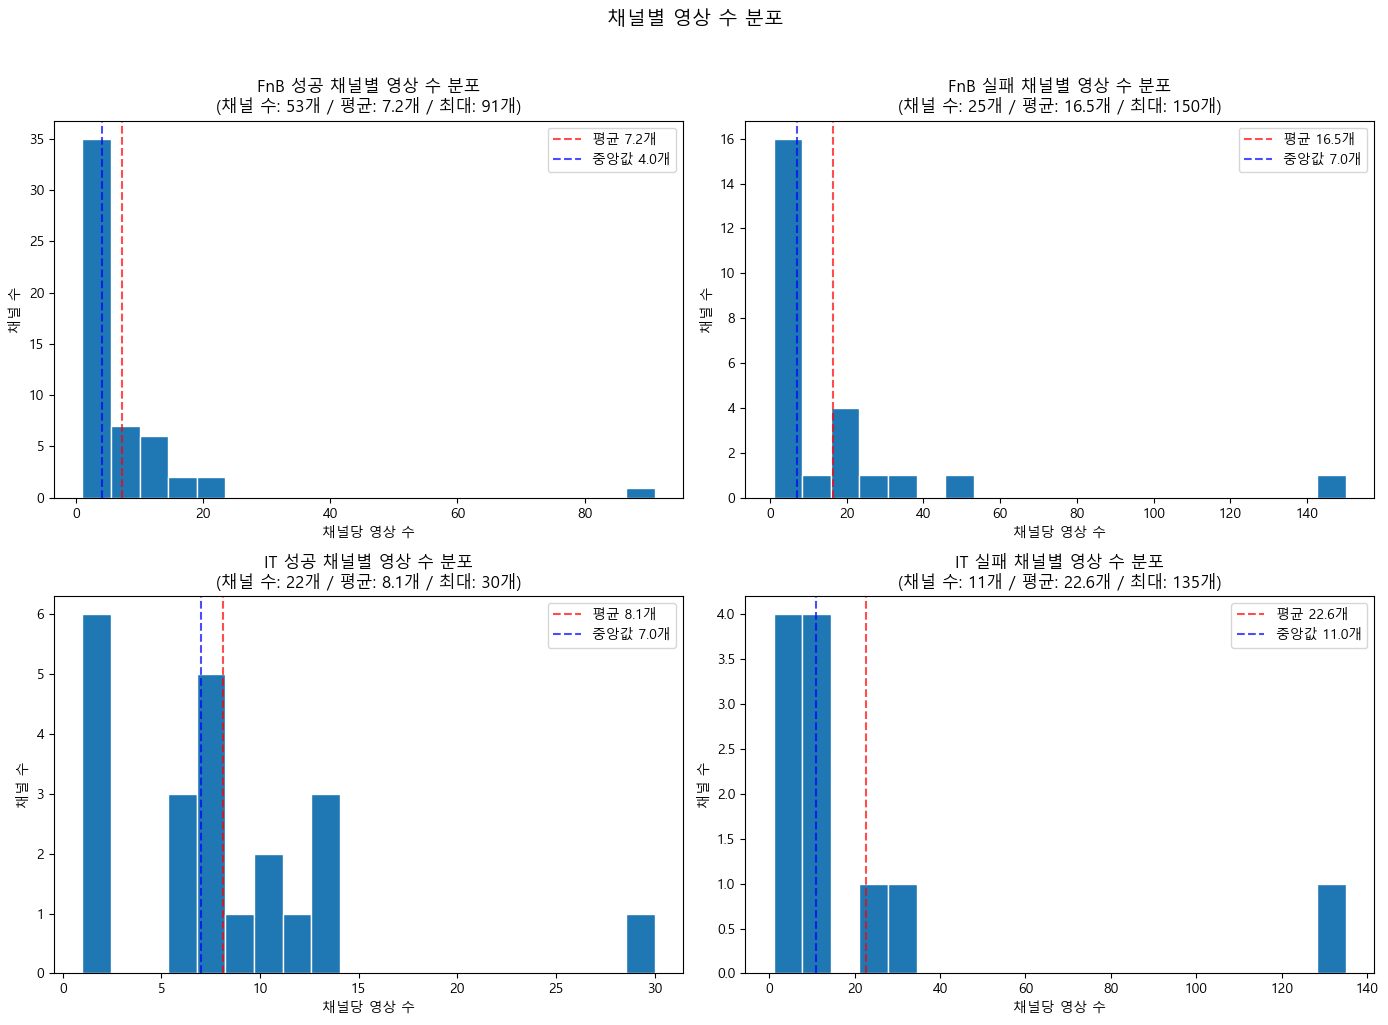

In [6]:
# 채널별 영상 수 분포 히스토그램
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, df) in zip(axes.flatten(), [
    ('FnB 성공', df_fnb_success), ('FnB 실패', df_fnb_fail),
    ('IT 성공',  df_it_success),  ('IT 실패',  df_it_fail)
]):
    ch_dist = df.groupby('채널명').size()
    
    ax.hist(ch_dist, bins=20, edgecolor='white')
    ax.set_title(f'{name} 채널별 영상 수 분포\n'
                 f'(채널 수: {len(ch_dist)}개 / 평균: {ch_dist.mean():.1f}개 / 최대: {ch_dist.max()}개)',
                 fontsize=12)
    ax.set_xlabel('채널당 영상 수')
    ax.set_ylabel('채널 수')
    ax.axvline(x=ch_dist.mean(), color='red', linestyle='--', alpha=0.7, label=f'평균 {ch_dist.mean():.1f}개')
    ax.axvline(x=ch_dist.median(), color='blue', linestyle='--', alpha=0.7, label=f'중앙값 {ch_dist.median():.1f}개')
    ax.legend()

plt.suptitle('채널별 영상 수 분포', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# 모든 그래프에서 분포가 편향되어 있어 채널을 기준으로 샘플링하긴 어려워보임 
# -> 채널별 비례를 하더라도 영상이 1~2개 뽑히는 경우가 많아 통계적으로 가치가 있다고 보긴 어렵지 않을까 싶음
# 대표성을 지니기에는 채널당 샘플 수가 너무 편향되어 있기 때문임
# 층화 샘플링의 기준인 채널에서 최소 30개 이상은 뽑혀야 하는데, 그렇지 못하는 경우가 너무 많음

---
### 숏츠데이터 샘플링 기준 고민

##### 후보 1. 채널 규모별 샘플링
- 도하님이 제시해주셨던 구독자 수 기준으로 그룹화
    - 구독자 수 1000명 미만 : 기타
    - 구독자 수 1000명 이상, 1만명 미만 : 나노(Nano) 
    - 구독자 수 1만명 이상, 5만명 미만 : 마이크로(Micro)
    - 구독자 수 5만명 이상, 10만명 미만 : 미드(Mid)
    - 구독자 수 10만명 이상, 50만명 미만 : 매크로(Macro)
    - 구독자 수 50만명 이상 : 메가(Mega)

In [7]:
# 구독자 수별 티어 정보 추가 함수 정의

def add_channel_tier_industry(df):
    # 채널별 구독자 수를 하나만 가져오기 위해 .first() 사용
    # 같은 채널의 영상이 여러 개 있어 구독자 수가 중복으로 존재하지만
    # 수집 시점 기준으로 동일한 값이므로 첫 번째 값만 사용
    ch_subscribers = df.groupby('채널명')['구독자수'].first()
    
    tier_map = {}
    for ch, sub in ch_subscribers.items():
        if sub < 1000:
            tier_map[ch] = '0_기타 (1천 미만)'
        elif sub < 10000:
            tier_map[ch] = '1_나노 (1천~1만)'
        elif sub < 50000:
            tier_map[ch] = '2_마이크로 (1만~5만)'
        elif sub < 100000:
            tier_map[ch] = '3_미드 (5만~10만)'
        elif sub < 500000:
            tier_map[ch] = '4_매크로 (10만~50만)'
        else:
            tier_map[ch] = '5_메가 (50만 이상)'
            
    df['채널규모티어'] = df['채널명'].map(tier_map)
    
    return df

In [8]:
# 티어 추가
df_fnb_success = add_channel_tier_industry(df_fnb_success)
df_fnb_fail    = add_channel_tier_industry(df_fnb_fail)
df_it_success  = add_channel_tier_industry(df_it_success)
df_it_fail     = add_channel_tier_industry(df_it_fail)

# 티어별 채널 수 및 영상 수 분포 확인
for domain, df_success, df_fail in [
    ('FnB', df_fnb_success, df_fnb_fail),
    ('IT',  df_it_success,  df_it_fail)
]:
    print(f"\n{'='*50}")
    print(f"[{domain}]")
    print(f"{'='*50}")
    for label, df in [('성공', df_success), ('실패', df_fail)]:
        print(f"\n  [{label}]")
        tier_summary = df.groupby('채널규모티어').agg(
            채널수=('채널명', 'nunique'),
            영상수=('video_id', 'count')
        )
        tier_summary['채널당평균'] = (
            tier_summary['영상수'] / tier_summary['채널수']
        ).round(1)
        display(tier_summary)


[FnB]

  [성공]


,채널수,영상수,채널당평균
채널규모티어,,,
0_기타 (1천 미만),11,43,3.9
1_나노 (1천~1만),13,104,8.0
2_마이크로 (1만~5만),12,142,11.8
3_미드 (5만~10만),5,20,4.0
4_매크로 (10만~50만),10,51,5.1
5_메가 (50만 이상),2,24,12.0



  [실패]


,채널수,영상수,채널당평균
채널규모티어,,,
1_나노 (1천~1만),1,1,1.0
2_마이크로 (1만~5만),6,37,6.2
3_미드 (5만~10만),5,69,13.8
4_매크로 (10만~50만),11,110,10.0
5_메가 (50만 이상),2,196,98.0



[IT]

  [성공]


,채널수,영상수,채널당평균
채널규모티어,,,
0_기타 (1천 미만),1,2,2.0
1_나노 (1천~1만),9,82,9.1
2_마이크로 (1만~5만),6,38,6.3
3_미드 (5만~10만),4,50,12.5
4_매크로 (10만~50만),1,1,1.0
5_메가 (50만 이상),1,6,6.0



  [실패]


,채널수,영상수,채널당평균
채널규모티어,,,
2_마이크로 (1만~5만),7,77,11.0
3_미드 (5만~10만),2,24,12.0
4_매크로 (10만~50만),1,13,13.0
5_메가 (50만 이상),1,135,135.0


##### 후보 2. 업로드 연도별 그룹화 -> 층화 샘플링
- 2021 ~ 2026년으로 그룹화해서 샘플링하면 데이터 분포가 어떨까?

In [9]:
# 영상 업로드 연도별 그룹화했을 때, 각 그룹의 샘플 수 확인
for domain, df_success, df_fail in [
    ('FnB', df_fnb_success, df_fnb_fail),
    ('IT',  df_it_success,  df_it_fail)
]:
    print(f"\n{'='*60}")
    print(f"[{domain}]")
    print(f"{'='*60}")
    for label, df in [('성공', df_success), ('실패', df_fail)]:
        groups = df.groupby('upload_year').size()
        print(f"\n  [{label}] 그룹 수: {len(groups)}개 / "
              f"그룹당 평균: {groups.mean():.1f}개 / "
              f"최소: {groups.min()}개 / "
              f"최대: {groups.max()}개")
        print(groups.to_string())


[FnB]

  [성공] 그룹 수: 5개 / 그룹당 평균: 76.8개 / 최소: 26개 / 최대: 126개
upload_year
2022     26
2023     54
2024     99
2025    126
2026     79

  [실패] 그룹 수: 6개 / 그룹당 평균: 68.8개 / 최소: 7개 / 최대: 123개
upload_year
2021      7
2022     59
2023    123
2024    102
2025    114
2026      8

[IT]

  [성공] 그룹 수: 5개 / 그룹당 평균: 35.8개 / 최소: 2개 / 최대: 79개
upload_year
2022     2
2023    16
2024    41
2025    79
2026    41

  [실패] 그룹 수: 5개 / 그룹당 평균: 49.8개 / 최소: 2개 / 최대: 98개
upload_year
2022    14
2023    48
2024    87
2025    98
2026     2


##### 후보3. 유튜브 숏츠의 성장 단계에 따른 그룹화

In [10]:
# -------------------------------------------------------
# 유튜브 숏츠 성장 단계별 그룹화
# 도입기: 2021-10 ~ 2022-12 (전 세계 출시 ~ 파트너 프로그램 편입 전)
# 성장기: 2023-01 ~ 2023-12 (파트너 프로그램 편입 ~ 월간 활성 사용자 20억 돌파)
# 성숙기: 2024-01 ~ 2026-03 (최대 길이 3분 확대, TikTok 참여율 추월)
# -------------------------------------------------------

def add_growth_stage(df):
    # 업로드일시 datetime 변환
    df['업로드일시'] = pd.to_datetime(df['업로드일시'])
    
    def classify_stage(date):
        if date < pd.Timestamp('2023-01-01'):
            return '1_도입기 (2021.10~2022.12)'
        elif date < pd.Timestamp('2024-01-01'):
            return '2_성장기 (2023.01~2023.12)'
        else:
            return '3_성숙기 (2024.01~2026.03)'
    
    df['성장단계'] = df['업로드일시'].apply(classify_stage)
    return df

# 성장 단계 추가
df_fnb_success = add_growth_stage(df_fnb_success)
df_fnb_fail    = add_growth_stage(df_fnb_fail)
df_it_success  = add_growth_stage(df_it_success)
df_it_fail     = add_growth_stage(df_it_fail)

# 성장 단계별 분포 확인
for domain, df_success, df_fail in [
    ('FnB', df_fnb_success, df_fnb_fail),
    ('IT',  df_it_success,  df_it_fail)
]:
    print(f"\n{'='*50}")
    print(f"[{domain}]")
    print(f"{'='*50}")
    for label, df in [('성공', df_success), ('실패', df_fail)]:
        groups = df.groupby('성장단계').size()
        print(f"\n  [{label}] 그룹 수: {len(groups)}개 / "
              f"그룹당 평균: {groups.mean():.1f}개 / "
              f"최소: {groups.min()}개 / "
              f"최대: {groups.max()}개")
        print(groups.to_string())


[FnB]

  [성공] 그룹 수: 3개 / 그룹당 평균: 128.0개 / 최소: 26개 / 최대: 304개
성장단계
1_도입기 (2021.10~2022.12)     26
2_성장기 (2023.01~2023.12)     54
3_성숙기 (2024.01~2026.03)    304

  [실패] 그룹 수: 3개 / 그룹당 평균: 137.7개 / 최소: 66개 / 최대: 224개
성장단계
1_도입기 (2021.10~2022.12)     66
2_성장기 (2023.01~2023.12)    123
3_성숙기 (2024.01~2026.03)    224

[IT]

  [성공] 그룹 수: 3개 / 그룹당 평균: 59.7개 / 최소: 2개 / 최대: 161개
성장단계
1_도입기 (2021.10~2022.12)      2
2_성장기 (2023.01~2023.12)     16
3_성숙기 (2024.01~2026.03)    161

  [실패] 그룹 수: 3개 / 그룹당 평균: 83.0개 / 최소: 14개 / 최대: 187개
성장단계
1_도입기 (2021.10~2022.12)     14
2_성장기 (2023.01~2023.12)     48
3_성숙기 (2024.01~2026.03)    187


##### 후보4. 무작위 샘플링 + 모집단의 성공/실패 비율 유지

In [11]:
# -------------------------------------------------------
# 단순 무작위 샘플링 + 모집단 성공/실패 비율 유지
# -------------------------------------------------------

# 모집단 비율 계산
fnb_total = len(df_fnb_success) + len(df_fnb_fail)
fnb_success_ratio = len(df_fnb_success) / fnb_total
fnb_fail_ratio    = len(df_fnb_fail)    / fnb_total

it_total = len(df_it_success) + len(df_it_fail)
it_success_ratio = len(df_it_success) / it_total
it_fail_ratio    = len(df_it_fail)    / it_total

print(f"[모집단 비율]")
print(f"  FnB: 성공 {fnb_success_ratio:.1%} / 실패 {fnb_fail_ratio:.1%}")
print(f"  IT:  성공 {it_success_ratio:.1%} / 실패 {it_fail_ratio:.1%}")

print(f"\n{'목표':^6} | {'FnB 성공':^8} {'FnB 실패':^8} | {'IT 성공':^8} {'IT 실패':^8} | {'총합':^6}")
print(f"{'-'*6}-+-{'-'*8}-{'-'*8}-+-{'-'*8}-{'-'*8}-+-{'-'*6}-+-{'-'*8}")

for n in list(range(30, 81)) + list(range(90, 251, 10)):

    fnb_success_n = min(round(n * fnb_success_ratio), len(df_fnb_success))
    fnb_fail_n    = min(round(n * fnb_fail_ratio),    len(df_fnb_fail))
    it_success_n  = min(round(n * it_success_ratio),  len(df_it_success))
    it_fail_n     = min(round(n * it_fail_ratio),     len(df_it_fail))

    total    = fnb_success_n + fnb_fail_n + it_success_n + it_fail_n
    vlm_time = total * 1.5 / 60

    print(f"{n:^6}개 | {fnb_success_n:^7}개 {fnb_fail_n:^7}개 | "
          f"{it_success_n:^7}개 {it_fail_n:^7}개 | "
          f"{total:^5}개")

[모집단 비율]
  FnB: 성공 48.2% / 실패 51.8%
  IT:  성공 41.8% / 실패 58.2%

  목표   |  FnB 성공   FnB 실패  |  IT 성공    IT 실패   |   총합  
-------+-------------------+-------------------+--------+---------
  30  개 |   14   개   16   개 |   13   개   17   개 |  60  개
  31  개 |   15   개   16   개 |   13   개   18   개 |  62  개
  32  개 |   15   개   17   개 |   13   개   19   개 |  64  개
  33  개 |   16   개   17   개 |   14   개   19   개 |  66  개
  34  개 |   16   개   18   개 |   14   개   20   개 |  68  개
  35  개 |   17   개   18   개 |   15   개   20   개 |  70  개
  36  개 |   17   개   19   개 |   15   개   21   개 |  72  개
  37  개 |   18   개   19   개 |   15   개   22   개 |  74  개
  38  개 |   18   개   20   개 |   16   개   22   개 |  76  개
  39  개 |   19   개   20   개 |   16   개   23   개 |  78  개
  40  개 |   19   개   21   개 |   17   개   23   개 |  80  개
  41  개 |   20   개   21   개 |   17   개   24   개 |  82  개
  42  개 |   20   개   22   개 |   18   개   24   개 |  84  개
  43  개 |   21   개   22   개 |   18   개   25   개 |  86  개
  44  개 |   21 

---
만약에 희상님 의견대로 수집된 표본에서 한 채널당 최대 영상 개수를 제한한다면?

In [12]:
# 채널당 상한선별 확보 가능한 샘플 수 확인
# 도메인당 100개 이상 확보 가능한 cap 기준 탐색

for cap in [5, 10, 15, 20, 25, 30]:
    print(f"\n[채널당 최대 {cap}개 제한]")
    for domain, df_success, df_fail in [
        ('FnB', df_fnb_success, df_fnb_fail),
        ('IT',  df_it_success,  df_it_fail)
    ]:
        # 모집단 비율 계산
        total = len(df_success) + len(df_fail)
        success_ratio = len(df_success) / total
        fail_ratio    = len(df_fail)    / total

        # 채널당 cap 적용 후 확보 가능한 샘플 수
        success_capped = df_success.groupby('채널명').size().clip(upper=cap).sum()
        fail_capped    = df_fail.groupby('채널명').size().clip(upper=cap).sum()
        domain_total   = success_capped + fail_capped

        print(f"  {domain}: 성공 최대 {success_capped}개 / 실패 최대 {fail_capped}개 "
              f"/ 합계 {domain_total}개 "
              f"{'✅' if domain_total >= 100 else '❌'}")


[채널당 최대 5개 제한]
  FnB: 성공 최대 185개 / 실패 최대 100개 / 합계 285개 ✅
  IT: 성공 최대 90개 / 실패 최대 47개 / 합계 137개 ✅

[채널당 최대 10개 제한]
  FnB: 성공 최대 258개 / 실패 최대 157개 / 합계 415개 ✅
  IT: 성공 최대 144개 / 실패 최대 82개 / 합계 226개 ✅

[채널당 최대 15개 제한]
  FnB: 성공 최대 297개 / 실패 최대 198개 / 합계 495개 ✅
  IT: 성공 최대 164개 / 실패 최대 105개 / 합계 269개 ✅

[채널당 최대 20개 제한]
  FnB: 성공 최대 312개 / 실패 최대 233개 / 합계 545개 ✅
  IT: 성공 최대 169개 / 실패 최대 120개 / 합계 289개 ✅

[채널당 최대 25개 제한]
  FnB: 성공 최대 318개 / 실패 최대 258개 / 합계 576개 ✅
  IT: 성공 최대 174개 / 실패 최대 134개 / 합계 308개 ✅

[채널당 최대 30개 제한]
  FnB: 성공 최대 323개 / 실패 최대 276개 / 합계 599개 ✅
  IT: 성공 최대 179개 / 실패 최대 144개 / 합계 323개 ✅


In [13]:
# 도메인당 100개 샘플링 시 cap별 성공/실패 수
print(f"{'cap':^6} | {'FnB 성공':^8} {'FnB 실패':^8} {'FnB 합계':^8} | {'IT 성공':^8} {'IT 실패':^8} {'IT 합계':^8}")
print(f"{'-'*70}")

for cap in [5, 10, 15, 20, 25, 30]:
    for domain, df_success, df_fail in [
        ('FnB', df_fnb_success, df_fnb_fail),
        ('IT',  df_it_success,  df_it_fail)
    ]:
        total = len(df_success) + len(df_fail)
        success_ratio = len(df_success) / total
        fail_ratio    = len(df_fail)    / total

        success_n = round(100 * success_ratio)
        fail_n    = round(100 * fail_ratio)

        # cap 초과 방지
        success_capped = df_success.groupby('채널명').size().clip(upper=cap).sum()
        fail_capped    = df_fail.groupby('채널명').size().clip(upper=cap).sum()

        success_n = min(success_n, success_capped)
        fail_n    = min(fail_n,    fail_capped)

        if domain == 'FnB':
            fnb_s, fnb_f = success_n, fail_n
        else:
            print(f"{cap:^6}개 | {fnb_s:^7}개 {fnb_f:^7}개 {fnb_s+fnb_f:^7}개 | "
                  f"{success_n:^7}개 {fail_n:^7}개 {success_n+fail_n:^7}개")

 cap   |  FnB 성공   FnB 실패   FnB 합계  |  IT 성공    IT 실패    IT 합계  
----------------------------------------------------------------------
  5   개 |   48   개   52   개   100  개 |   42   개   47   개   89   개
  10  개 |   48   개   52   개   100  개 |   42   개   58   개   100  개
  15  개 |   48   개   52   개   100  개 |   42   개   58   개   100  개
  20  개 |   48   개   52   개   100  개 |   42   개   58   개   100  개
  25  개 |   48   개   52   개   100  개 |   42   개   58   개   100  개
  30  개 |   48   개   52   개   100  개 |   42   개   58   개   100  개


In [14]:
# 채널당 cap 10개 적용 후 채널별 분포 확인
# 실제로 특정 채널 영향이 줄어드는지 확인

for domain, df_success, df_fail in [
    ('FnB', df_fnb_success, df_fnb_fail),
    ('IT',  df_it_success,  df_it_fail)
]:
    print(f"\n{'='*50}")
    print(f"[{domain}] 채널당 cap 10개 적용 전/후 비교")
    print(f"{'='*50}")

    for label, df in [('성공', df_success), ('실패', df_fail)]:
        ch_dist = df.groupby('채널명').size().sort_values(ascending=False)
        ch_capped = ch_dist.clip(upper=10)

        print(f"\n  [{label}]")
        print(f"  {'채널명':<30} {'원본':>6} {'cap 적용':>8} {'비율(원본)':>10} {'비율(cap)':>10}")
        print(f"  {'-'*65}")
        for ch in ch_dist.index:
            orig = ch_dist[ch]
            capped = ch_capped[ch]
            orig_pct = orig / ch_dist.sum() * 100
            capped_pct = capped / ch_capped.sum() * 100
            print(f"  {ch:<30} {orig:>5}개 {capped:>7}개 {orig_pct:>9.1f}% {capped_pct:>9.1f}%")
        print(f"\n  총합: {ch_dist.sum()}개 → {ch_capped.sum()}개")


[FnB] 채널당 cap 10개 적용 전/후 비교

  [성공]
  채널명                                원본   cap 적용     비율(원본)    비율(cap)
  -----------------------------------------------------------------
  동원TV                              91개      10개      23.7%       3.9%
  테헤란로405                           21개      10개       5.5%       3.9%
  CU [씨유튜브]                         19개      10개       4.9%       3.9%
  Samyangfoods삼양식품                  16개      10개       4.2%       3.9%
  세상에서 가장 작은 카페, 카누                 15개      10개       3.9%       3.9%
  사조대림                              14개      10개       3.6%       3.9%
  이마트24 | ALLDAY HIGHLIGHT          14개      10개       3.6%       3.9%
  킴스클럽 공식                           12개      10개       3.1%       3.9%
  농심 nongshim                       12개      10개       3.1%       3.9%
  🍦Buza Company🍦                    11개      10개       2.9%       3.9%
  오뚜기 Daily                         11개      10개       2.9%       3.9%
  칠성레이블                              9개    

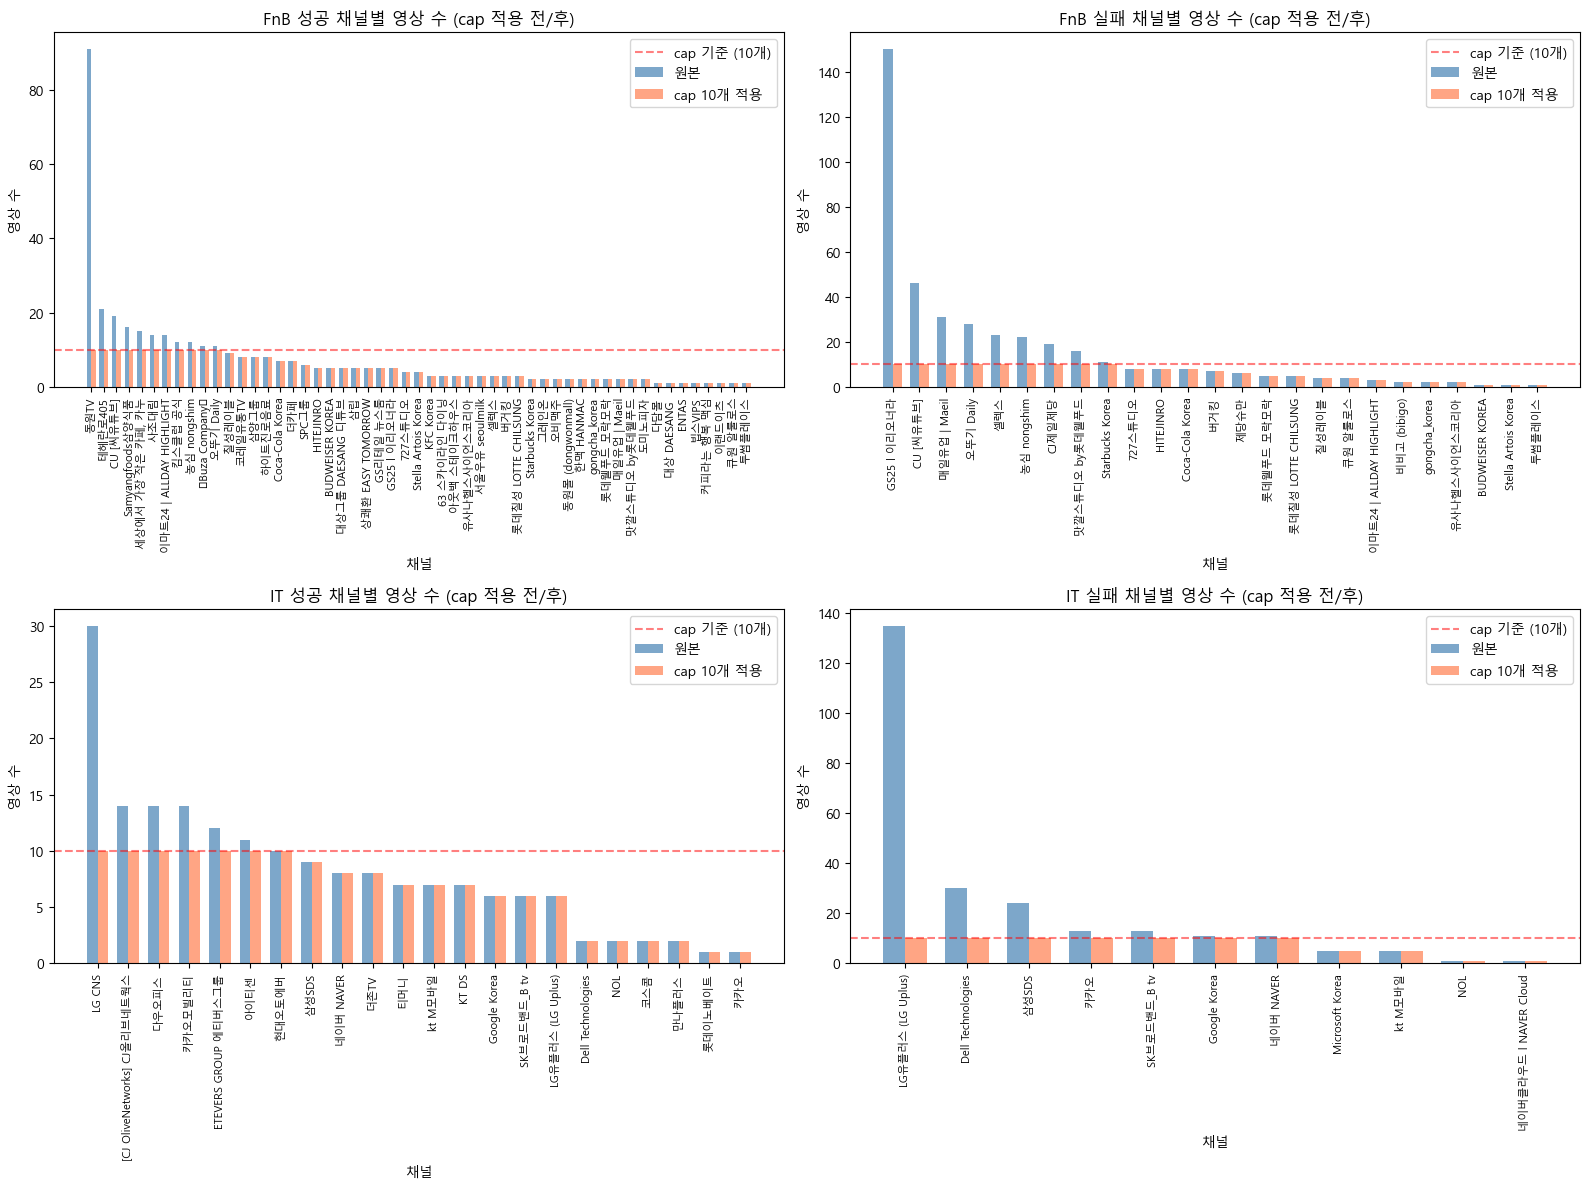

In [15]:
# 채널당 cap 10개 적용 전/후 채널별 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax_row, (domain, df_success, df_fail) in enumerate([
    ('FnB', df_fnb_success, df_fnb_fail),
    ('IT',  df_it_success,  df_it_fail)
]):
    for ax_col, (label, df) in enumerate([('성공', df_success), ('실패', df_fail)]):
        ax = axes[ax_row][ax_col]

        ch_dist   = df.groupby('채널명').size().sort_values(ascending=False)
        ch_capped = ch_dist.clip(upper=10)

        x = range(len(ch_dist))
        width = 0.35

        ax.bar([i - width/2 for i in x], ch_dist.values,
               width=width, label='원본', alpha=0.7, color='steelblue')
        ax.bar([i + width/2 for i in x], ch_capped.values,
               width=width, label='cap 10개 적용', alpha=0.7, color='coral')

        ax.set_title(f'{domain} {label} 채널별 영상 수 (cap 적용 전/후)', fontsize=12)
        ax.set_xlabel('채널')
        ax.set_ylabel('영상 수')
        ax.set_xticks(list(x))
        ax.set_xticklabels(ch_dist.index, rotation=90, fontsize=8)
        ax.axhline(y=10, color='red', linestyle='--', alpha=0.5, label='cap 기준 (10개)')
        ax.legend()

plt.tight_layout()
plt.show()

In [17]:
print(df_fnb_success.columns.tolist())

['video_id', 'title', 'channel_id', '채널명', 'description', '업로드일시', 'tags', '조회수', '좋아요수', '댓글수', '영상길이(초)', 'definition', 'license', 'embeddable', 'has_paid_product_placement', 'thumbnail', 'caption', 'final_url', 'instream_type', 'channel_handle', 'channel_tier', '구독자수', 'domain', 'description_missing_flag', 'tags_missing_flag', '참여율(ER)', '조회수 대비 좋아요율', '조회수 대비 댓글률', 'wei', 'description_length', 'category_name', 'upload_year', 'upload_month', 'upload_dayofweek', 'upload_hour', 'tags_count', 'upload_quarter', 'upload_ym_quarter', 'upload_ymd', '경과일수', '도달률(RR)', '일평균 조회수', 'RR_백분위', 'ER_백분위', 'score1', '조회수성과', '좋아요성과', '댓글성과', '조회수성과_상위1%', '조회수성과_상위5%', '좋아요성과_상위1%', '좋아요성과_상위5%', '댓글성과_상위1%', '댓글성과_상위5%', 'score2', 'grade', '채널규모티어', '성장단계']


In [ ]:
def stratified_sampling(df_success, df_fail, total_n=100, cap=10, random_state=42):
    
    # 모집단 비율 계산
    total = len(df_success) + len(df_fail)
    success_n = round(total_n * len(df_success) / total)
    fail_n    = round(total_n * len(df_fail)    / total)
    
    # 채널당 cap 적용
    def apply_cap(df, cap, random_state):
        sampled = []
        for channel, group in df.groupby('채널명'):
            sampled.append(group.sample(min(len(group), cap),
                                        random_state=random_state))
        return pd.concat(sampled)
    
    df_success_capped = apply_cap(df_success, cap, random_state)
    df_fail_capped    = apply_cap(df_fail,    cap, random_state)
    
    # cap 적용 후 샘플 수 조정
    success_n = min(success_n, len(df_success_capped))
    fail_n    = min(fail_n,    len(df_fail_capped))
    
    # 무작위 샘플링
    sample_success = df_success_capped.sample(success_n, random_state=random_state)
    sample_fail    = df_fail_capped.sample(fail_n, random_state=random_state)
    
    return sample_success, sample_fail

# FnB 샘플링
fnb_sample_success, fnb_sample_fail = stratified_sampling(
    df_fnb_success, df_fnb_fail, total_n=100, cap=10
)

# IT 샘플링
it_sample_success, it_sample_fail = stratified_sampling(
    df_it_success, df_it_fail, total_n=100, cap=10
)

# 결과 확인
for domain, sample_success, sample_fail in [
    ('FnB', fnb_sample_success, fnb_sample_fail),
    ('IT',  it_sample_success,  it_sample_fail)
]:
    print(f"\n[{domain}]")
    print(f"  성공: {len(sample_success)}개 / 실패: {len(sample_fail)}개 / 합계: {len(sample_success)+len(sample_fail)}개")
    
    print(f"\n  [성공 채널별 분포]")
    display(
        sample_success.groupby('채널명').size()
        .reset_index(name='영상수')
        .sort_values('영상수', ascending=False)
        .reset_index(drop=True)
    )
    
    print(f"\n  [실패 채널별 분포]")
    display(
        sample_fail.groupby('채널명').size()
        .reset_index(name='영상수')
        .sort_values('영상수', ascending=False)
        .reset_index(drop=True)
    )


[FnB]
  성공: 48개 / 실패: 52개 / 합계: 100개

  [성공 채널별 분포]


,채널명,영상수
0,동원TV,4
1,CU [씨유튜브],3
2,오뚜기 Daily,3
3,Stella Artois Korea,3
4,칠성레이블,3
5,KFC Korea,2
6,Samyangfoods삼양식품,2
7,삼립,2
8,사조대림,2
9,GS25 l 이리오너라,2



  [실패 채널별 분포]


,채널명,영상수
0,오뚜기 Daily,6
1,CJ제일제당,5
2,CU [씨유튜브],4
3,농심 nongshim,4
4,Coca-Cola Korea,4
5,셀렉스,4
6,롯데웰푸드 모락모락,3
7,맛깔스튜디오 by롯데웰푸드,3
8,GS25 l 이리오너라,2
9,칠성레이블,2



[IT]
  성공: 42개 / 실패: 58개 / 합계: 100개

  [성공 채널별 분포]


,채널명,영상수
0,ETEVERS GROUP 에티버스그룹,4
1,카카오모빌리티,4
2,삼성SDS,4
3,LG CNS,3
4,kt M모바일,3
5,네이버 NAVER,3
6,아이티센,3
7,[CJ OliveNetworks] CJ올리브네트웍스,3
8,티머니,3
9,Google Korea,2



  [실패 채널별 분포]


,채널명,영상수
0,Dell Technologies,8
1,Google Korea,8
2,SK브로드밴드_B tv,8
3,삼성SDS,7
4,카카오,6
5,LG유플러스 (LG Uplus),5
6,kt M모바일,5
7,네이버 NAVER,5
8,Microsoft Korea,4
9,NOL,1
